# Public Transport Demand & Planning Analysis

## Kharagpur → Kolkata Corridor

This notebook performs exploratory data analysis on the synthetic
90-day multimodal public transport dataset generated for the
Kharagpur–Kolkata corridor.

The analysis focuses on understanding:

- Passenger demand patterns
- Rail and bus demand behavior
- Weekday and weekend variation
- Festival/stress-day demand
- Origin–destination flows
- Demand variability and potential capacity pressure

The objective is to establish whether the generated dataset behaves
as a meaningful transportation-demand scenario before developing
forecasting and optimization models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
    / "transport_demand_90days.csv"
)

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (720, 7)


In [3]:
df.head(10)

,date,origin,destination,mode,passengers,festival,weekend
0,2025-08-01,Kharagpur,Midnapore,Rail,12298,0,0
1,2025-08-01,Kharagpur,Midnapore,Bus,7867,0,0
2,2025-08-01,Midnapore,Uluberia,Rail,14453,0,0
3,2025-08-01,Midnapore,Uluberia,Bus,7688,0,0
4,2025-08-01,Uluberia,Howrah,Rail,12848,0,0
5,2025-08-01,Uluberia,Howrah,Bus,7775,0,0
6,2025-08-01,Howrah,Kolkata,Rail,16184,0,0
7,2025-08-01,Howrah,Kolkata,Bus,7099,0,0
8,2025-08-02,Kharagpur,Midnapore,Rail,21093,1,1
9,2025-08-02,Kharagpur,Midnapore,Bus,15338,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         720 non-null    datetime64[ns]
 1   origin       720 non-null    object        
 2   destination  720 non-null    object        
 3   mode         720 non-null    object        
 4   passengers   720 non-null    int64         
 5   festival     720 non-null    int64         
 6   weekend      720 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 39.5+ KB


In [5]:
df.describe()

,date,passengers,festival,weekend
count,720,720.000000,720.000000,720.000000
mean,2025-09-14 12:00:00,10596.976389,0.077778,0.288889
min,2025-08-01 00:00:00,3999.000000,0.000000,0.000000
25%,2025-08-23 00:00:00,7033.750000,0.000000,0.000000
50%,2025-09-14 12:00:00,10565.500000,0.000000,0.000000
75%,2025-10-07 00:00:00,13107.250000,0.000000,1.000000
max,2025-10-29 00:00:00,28543.000000,1.000000,1.000000
std,NaN,4247.767577,0.268008,0.453561


## 2. Data Quality Validation

Before analyzing demand patterns, the dataset is checked for structural
consistency, duplicate records, missing values, invalid passenger counts,
and expected corridor coverage.

In [6]:
# Basic data-quality checks

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("Unique dates:", df["date"].nunique())
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Negative passenger counts:", (df["passengers"] < 0).sum())

print("\nTransport modes:")
print(df["mode"].value_counts())

print("\nFestival observations:")
print(df["festival"].value_counts())

print("\nWeekend observations:")
print(df["weekend"].value_counts())

Number of rows: 720
Number of columns: 7
Unique dates: 90
Missing values: 0
Duplicate rows: 0
Negative passenger counts: 0

Transport modes:
mode
Rail    360
Bus     360
Name: count, dtype: int64

Festival observations:
festival
0    664
1     56
Name: count, dtype: int64

Weekend observations:
weekend
0    512
1    208
Name: count, dtype: int64


## 3. Corridor Structure

The synthetic network represents four consecutive OD segments:

Kharagpur → Midnapore → Uluberia → Howrah → Kolkata

Demand is generated separately for rail and bus services on each segment.

In [7]:
# Check OD coverage

od_summary = (
    df.groupby(["origin", "destination"])
    .agg(
        observations=("passengers", "count"),
        average_demand=("passengers", "mean"),
        minimum_demand=("passengers", "min"),
        maximum_demand=("passengers", "max")
    )
    .round(2)
    .reset_index()
)

od_summary

,origin,destination,observations,average_demand,minimum_demand,maximum_demand
0,Howrah,Kolkata,180,10920.88,3999,28543
1,Kharagpur,Midnapore,180,10312.37,5879,22161
2,Midnapore,Uluberia,180,10516.24,4428,27198
3,Uluberia,Howrah,180,10638.41,5564,25896


## 4. Daily Corridor Demand

Individual OD observations are aggregated to obtain total daily passenger
demand across the entire corridor.

This provides the primary time series used later for short-term demand
forecasting.

In [8]:
daily_demand = (
    df.groupby("date")["passengers"]
    .sum()
    .reset_index(name="total_passengers")
)

daily_demand.head()

,date,total_passengers
0,2025-08-01,86212
1,2025-08-02,142452
2,2025-08-03,68537
3,2025-08-04,82590
4,2025-08-05,79014


In [9]:
daily_demand.describe()

,date,total_passengers
count,90,90.000000
mean,2025-09-14 12:00:00,84775.811111
min,2025-08-01 00:00:00,67256.000000
25%,2025-08-23 06:00:00,73104.000000
50%,2025-09-14 12:00:00,82060.500000
75%,2025-10-06 18:00:00,84346.750000
max,2025-10-29 00:00:00,154441.000000
std,NaN,19492.213373


### Daily Passenger Demand Over the 90-Day Scenario

The following visualization shows how total corridor demand changes over
time and allows us to identify recurring variation and demand spikes.

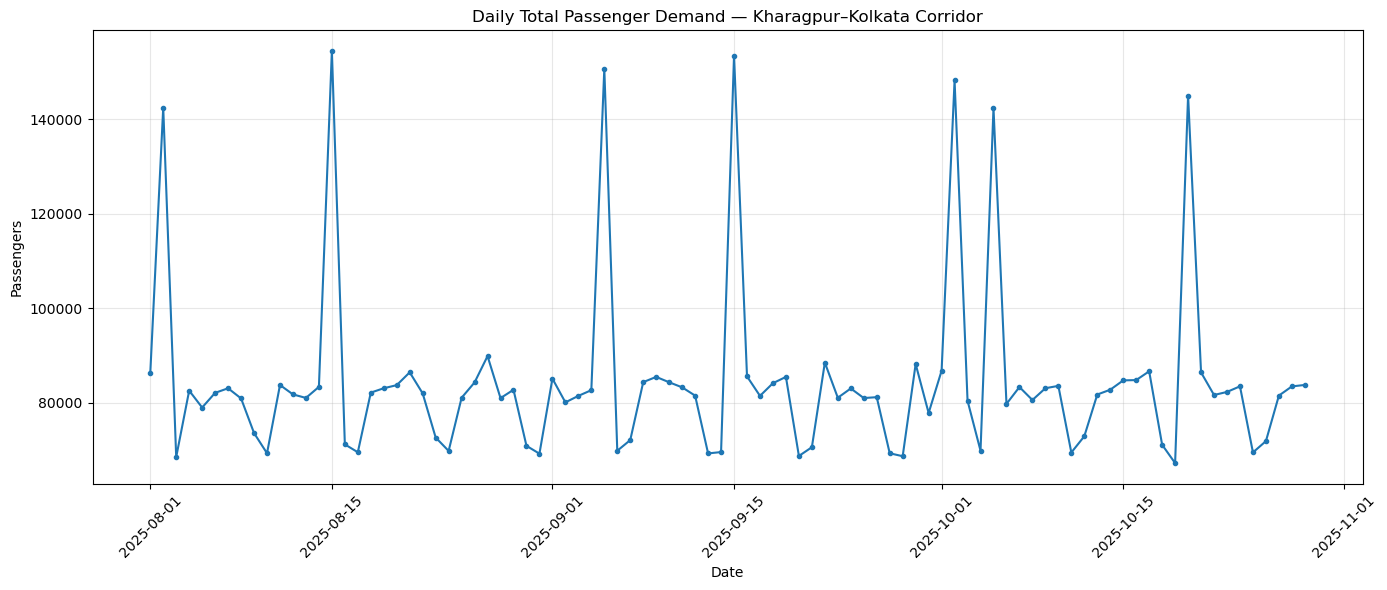

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_demand["date"],
    daily_demand["total_passengers"],
    marker="o",
    markersize=3
)

plt.title("Daily Total Passenger Demand — Kharagpur–Kolkata Corridor")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Festival vs Normal-Day Demand

The synthetic scenario explicitly includes festival/stress dates.
We compare these observations with normal days to verify whether the
scenario produces the intended demand uplift.

In [11]:
festival_comparison = (
    df.groupby("festival")["passengers"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)

festival_comparison

,count,mean,std,min,max
festival,,,,,
0,664,9929.56,3298.15,3999,17309
1,56,18510.66,5967.29,9590,28543


In [12]:
normal_mean = df.loc[df["festival"] == 0, "passengers"].mean()
festival_mean = df.loc[df["festival"] == 1, "passengers"].mean()

uplift = (festival_mean / normal_mean - 1) * 100

print(f"Normal-day average demand: {normal_mean:,.0f}")
print(f"Festival-day average demand: {festival_mean:,.0f}")
print(f"Festival demand uplift: {uplift:.1f}%")

Normal-day average demand: 9,930
Festival-day average demand: 18,511
Festival demand uplift: 86.4%


In [13]:
FESTIVAL_FACTOR = 1.80

## 6. Rail vs Bus Demand

Rail and bus services have different baseline demand levels and variability.
Understanding these differences is important for later multimodal fleet
allocation.

In [14]:
mode_summary = (
    df.groupby("mode")["passengers"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)

mode_summary

,count,mean,std,min,max
mode,,,,,
Bus,360,7424.42,2104.59,3999,18656
Rail,360,13769.53,3394.37,9246,28543


<Figure size 800x500 with 0 Axes>

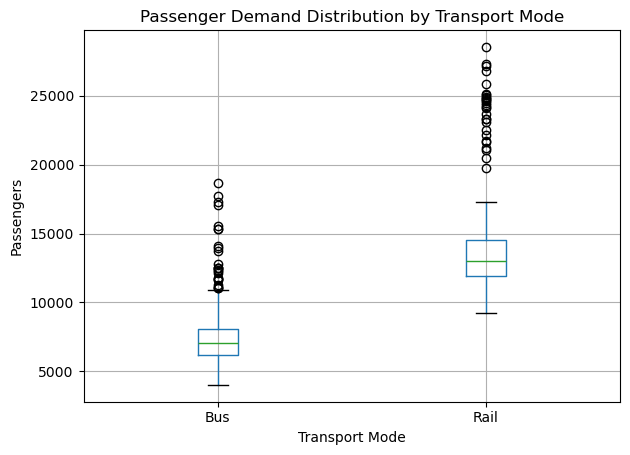

In [15]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="passengers",
    by="mode"
)

plt.title("Passenger Demand Distribution by Transport Mode")
plt.suptitle("")
plt.xlabel("Transport Mode")
plt.ylabel("Passengers")

plt.tight_layout()
plt.show()

## 7. Weekday vs Weekend Demand

Weekend demand is modeled separately to represent changes in travel
behavior compared with regular working days.

In [18]:
weekend_summary = (
    df.groupby("weekend")["passengers"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)

weekend_summary

,count,mean,std,min,max
weekend,,,,,
0,512,11053.92,4288.59,4883,28543
1,208,9472.19,3934.82,3999,24803


In [16]:
weekday_mean = df.loc[df["weekend"] == 0, "passengers"].mean()
weekend_mean = df.loc[df["weekend"] == 1, "passengers"].mean()

change = (weekend_mean / weekday_mean - 1) * 100

print(f"Weekday average demand: {weekday_mean:,.0f}")
print(f"Weekend average demand: {weekend_mean:,.0f}")
print(f"Weekend demand change: {change:.1f}%")

Weekday average demand: 11,054
Weekend average demand: 9,472
Weekend demand change: -14.3%


In [17]:
WEEKEND_FACTOR = 0.85

In [19]:
segment_summary = (
    df.groupby(["origin", "destination", "mode"])["passengers"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
    .reset_index()
)

segment_summary

,origin,destination,mode,count,mean,std,min,max
0,Howrah,Kolkata,Bus,90,6632.22,1785.77,3999,12756
1,Howrah,Kolkata,Rail,90,15209.54,3389.08,11671,28543
2,Kharagpur,Midnapore,Bus,90,8410.11,2511.40,5879,18656
3,Kharagpur,Midnapore,Rail,90,12214.63,2770.71,9246,22161
4,Midnapore,Uluberia,Bus,90,6644.67,1549.68,4428,12501
5,Midnapore,Uluberia,Rail,90,14387.81,3355.07,10341,27198
6,Uluberia,Howrah,Bus,90,8010.68,1841.01,5564,17699
7,Uluberia,Howrah,Rail,90,13266.14,3297.19,9931,25896


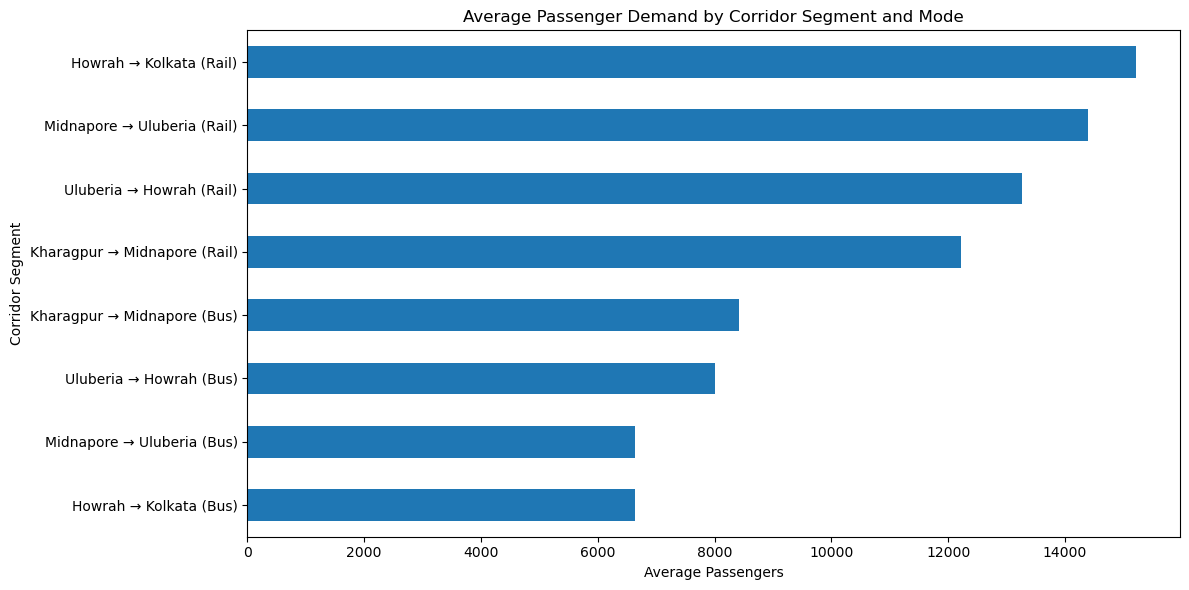

In [20]:
plt.figure(figsize=(12, 6))

segment_labels = (
    df["origin"] + " → " + df["destination"] + " (" + df["mode"] + ")"
)

segment_means = (
    df.assign(segment=segment_labels)
      .groupby("segment")["passengers"]
      .mean()
      .sort_values()
)

segment_means.plot(kind="barh")

plt.title("Average Passenger Demand by Corridor Segment and Mode")
plt.xlabel("Average Passengers")
plt.ylabel("Corridor Segment")
plt.tight_layout()
plt.show()